# **First Graph**
A minimal LangGraph that takes a name and message, calls an LLM, and returns the response.

In [1]:
from langchain_groq import ChatGroq   # Groq LLM wrapper for LangChain
from dotenv import load_dotenv
import os

load_dotenv()   # reads GROQ_API_KEY from your .env file

if os.environ.get('GROQ_API_KEY'):
    print("Groq API Key is set.")
else:
    raise ValueError("GROQ_API_KEY not found — add it to your .env file.")

Groq API Key is set.


In [ ]:
# Instantiate the LLM.
# model = "llama-3.3-70b-versatile" is fast, free-tier friendly, and hosted on Groq.
# temperature=0 keeps responses deterministic.
llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)

# Quick sanity check — invoke() sends a plain string as a HumanMessage.
llm.invoke("I want to know the meaning of water").content

'The term "water" can have multiple meanings depending on the context. Here are a few possible interpretations:\n\n1. **Chemical definition**: Water is a chemical compound composed of two hydrogen atoms and one oxygen atom, with the molecular formula H2O. It\'s a clear, colorless, odorless, and tasteless liquid that\'s essential for life on Earth.\n2. **Physical definition**: Water is a liquid substance that\'s found naturally on our planet, covering about 71% of the Earth\'s surface. It can exist in three main states: solid (ice), liquid (water), and gas (water vapor).\n3. **Biological definition**: Water is a vital component of all living organisms, making up a significant portion of their bodies. It\'s necessary for various biological processes, such as regulating body temperature, transporting nutrients and oxygen, and removing waste products.\n4. **Cultural and symbolic definition**: Water has significant cultural, spiritual, and symbolic meanings in many societies. It\'s often as

### **Step-1: Define The Schema**
The schema is the shared state dict that every node reads from and writes to.

In [5]:
from typing import TypedDict, List

class graph_schema(TypedDict):
    name: str      # the user's name, passed into the LLM prompt
    message: str   # the running message; updated by the welcome node

### **Step-2: Create The Node Functions**
Each node is a plain Python function `(state) -> state`.
It reads what it needs from state, does work, updates state, and returns it.

In [7]:
def welcome(schema: graph_schema) -> graph_schema:

    curr_name    = schema['name']      # pull the user's name from state
    curr_message = schema['message']   # pull the current message from state

    # Ask the LLM a personalised question using the name and message
    response = llm.invoke(f"My name is {curr_name}. {curr_message}").content

    # Overwrite the 'message' key with the enriched response
    schema['message'] = f"Your message was {curr_message}. Here's my response: {response}"

    return schema   # always return the (updated) state

### **Step-3: Create The State Graph**
StateGraph wires nodes together with edges.
- `add_node(name, fn)` registers a node.
- `add_edge(a, b)` draws an arrow from node a to node b.
- `START` and `END` are built-in sentinels.

In [8]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)   # pass in the schema so LangGraph knows the state shape

# Register the node (label, function)
graph.add_node("welcome", welcome)

# Wire the flow:  START → welcome → END
graph.add_edge(START, "welcome")
graph.add_edge("welcome", END)

### **Step-4: Compile The Graph**
`compile()` validates the graph and returns an executable `CompiledStateGraph`.

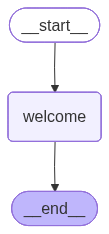

In [9]:
from IPython.display import Image

first_graph = graph.compile()

# draw_mermaid_png() renders a visual diagram of the graph — great for understanding
Image(first_graph.get_graph().draw_mermaid_png())

### **Step-5: Run The Graph**
`invoke(initial_state)` executes the graph from START to END and returns the final state.

In [10]:
first_graph.invoke({"name": "Ansh", "message": "How are you?"})
# Returns the full state dict after all nodes have run

{'name': 'Ansh',
 'message': "Your message was How are you?. Here's my response: Hello Ansh, I'm doing well, thanks for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you with any questions or tasks you may have. How about you, how's your day going so far?"}